# 01 - Data loading and cleaning

Our goal in this notebook is to decide exactly which GTFS stop rows are safe to use as graph nodes. We load the stops, routes, trips, and agency tables as text; test the stop identifiers and coordinates; and add two rough location labels to each valid stop: `region` (North, Center, Jerusalem, or South) and `metro` (Tel Aviv, Haifa, Jerusalem, Beer Sheva, or Periphery).

We want every cleaning decision to be countable. A broken coordinate would make the spatial results meaningless, while duplicate `stop_id` values could duplicate joins or collapse different rows into one graph node. We therefore apply each check separately and save its before/after counts instead of hiding all cleaning inside one expression.

**Question for this stage:** *What is the node set we will actually analyze, and did any raw stop rows have to be removed to get it?*

### Input

- `israel-public-transportation/stops.txt` - one row per physical stop / station (id, name, latitude, longitude, location type, parent station).
- `israel-public-transportation/routes.txt` - one row per route, with `route_type` (3 = bus, 2 = rail, ...) and the operator's `agency_id`.
- `israel-public-transportation/trips.txt` - one row per scheduled vehicle trip; this is the service-volume table.
- `israel-public-transportation/agency.txt` - one row per operator.

We do not need the 816 MB `stop_times.txt` file yet because this stage only prepares nodes and lookup tables. Adjacency is introduced in notebook 02.

### Output (all under `outputs/nb/01_data_preparation/`)

- `tables/stops_clean.csv` - the cleaned node table, plus the new `region` and `metro` columns.
- `tables/routes_clean.csv`, `tables/trips_clean.csv`, `tables/agencies_clean.csv` - pass-through copies with stable types, so later notebooks don't have to re-derive the parsing options.
- `tables/route_type_distribution.csv` - the number of routes and scheduled trips by GTFS mode.
- `tables/agency_trip_counts.csv` - scheduled trips per operator.
- `tables/data_cleaning_report.json` - the audit trail: row counts before and after each filter, region/metro breakdowns, and referential-integrity checks.
- `figures/*.png` - four descriptive figures.

### Dependencies

This is stage 01 and reads the raw GTFS files directly.

## Setting up the working environment

We start with the shared environment helper. `_ensure` installs only missing packages, and `find_repo_root()` searches upward for the GTFS folder or clones the project into `/content` in a fresh Colab runtime. The cell then changes to the repository root and defines `REPO`, `DATA`, and `OUT`, so the rest of our paths do not depend on the directory from which Jupyter was started.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## Libraries, stage folder, and tunable constants

This cell imports the libraries used below and creates `outputs/nb/01_data_preparation/tables` and `figures`. Keeping the stage output together makes it clear which notebook produced each file.

We keep the settings that affect cleaning or runtime in this cell:

- `LAT_MIN/LAT_MAX/LON_MIN/LON_MAX` define a deliberately generous box around Israel. Eilat and Metula sit comfortably inside it, so the filter is meant to catch values such as `0,0` or obvious digit errors rather than trim valid border stops.
- `SAVE_TRIPS_CSV` controls whether we write the large pass-through trips table. Turning it off saves time and about 28 MB but does not change the cleaning calculations.

In [2]:
# Third-party libraries used below. _ensure only installs what is missing.
_ensure("pandas", "numpy", "matplotlib")

import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- This notebook's own output folder (stage 01) ---
STAGE = OUT / "01_data_preparation"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ---
LAT_MIN, LAT_MAX = 29.0, 34.0   # generous bounding box around Israel
LON_MIN, LON_MAX = 34.0, 36.0
SAVE_TRIPS_CSV = True           # writing trips_clean.csv costs ~28 MB and tens of seconds

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

print("GTFS folder :", DATA)
print("Stage folder:", STAGE)

GTFS folder : /Users/seanfourman/Desktop/israel-transit-network-resilience/israel-public-transportation
Stage folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/01_data_preparation


## Displaying Hebrew labels correctly

The stop and operator names are mostly Hebrew. In this Matplotlib environment, raw logical-order Hebrew already renders correctly, so we leave `fix_he()` as a no-op and select fonts that include Hebrew glyphs. The cell removes a bidi patch if one is still present in the current kernel, because pre-reordering the text here would reverse it twice. We also disable scientific offset labels so later plots show small values directly.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# Pre-reordering with python-bidi would reverse it a second time, so fix_he stays a no-op
# and only a Hebrew-capable font is selected. A build without native bidi handling would
# need get_display; this build does not.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # Remove a bidi patch if the current kernel contains one, so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## Loading the raw GTFS tables

We load all four GTFS tables into a `raw` dictionary and keep these frames unchanged for before/after counts. Three parsing options are important for preserving the source values:

1. `dtype=str` treats identifiers as opaque text. Values such as `"01"` and `"1"` must remain different, so we convert only the coordinate columns later.
2. `keep_default_na=False` leaves empty text as an empty string and avoids treating legitimate strings such as `NA` as missing values.
3. `encoding="utf-8-sig"` removes a UTF-8 byte-order mark from the first header instead of leaving an invisible character attached to `stop_id` or another first column.

The printed shapes and column lists are our first schema check, and the preview confirms that the expected stop fields loaded under the expected names.

In [4]:
GTFS_FILES = {
    "stops":  "stops.txt",
    "routes": "routes.txt",
    "trips":  "trips.txt",
    "agency": "agency.txt",
}

def load_gtfs(name):
    """Load one GTFS table as raw text, with the three parsing decisions above."""
    path = DATA / GTFS_FILES[name]
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing. The GTFS feed is tracked in the repository - "
            "check that the clone completed and that DATA points at the feed folder."
        )
    return pd.read_csv(path, dtype=str, keep_default_na=False, encoding="utf-8-sig")

raw = {name: load_gtfs(name) for name in GTFS_FILES}

for name, df in raw.items():
    print(f"{name:7s} rows={len(df):>9,d}  columns={list(df.columns)}")

raw["stops"].head(3)

stops   rows=   34,932  columns=['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'zone_id']
routes  rows=    7,792  columns=['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_desc', 'route_type', 'route_color']
trips   rows=  420,133  columns=['route_id', 'service_id', 'trip_id', 'trip_headsign', 'direction_id', 'shape_id', 'wheelchair_accessible']
agency  rows=       37  columns=['agency_id', 'agency_name', 'agency_url', 'agency_timezone', 'agency_lang', 'agency_phone', 'agency_fare_url']


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,zone_id
0,1,38831,בי''ס בר לב/בן יהודה,רחוב: בן יהודה 74 עיר: כפר סבא רציף: קומה:,32.183985,34.917554,0,,38831
1,2,38832,הרצל/צומת בילו,רחוב: הרצל עיר: קרית עקרון רציף: קומה:,31.869152,34.819641,0,,38832
2,3,38833,מרכז ראשונים/הנחשול,רחוב: הנחשול 30 עיר: ראשון לציון רציף: קומה:,31.984553,34.782828,0,,38833


## Cleaning the stops table, one auditable filter at a time

The stops table will become the graph's node table, so this cell applies four checks in sequence. `record()` stores the row count before and after every check in `cleaning_steps`, which we save with the stage outputs.

1. We convert `stop_lat` and `stop_lon` with `errors="coerce"`; empty or nonnumeric values become `NaN` and are removed because we cannot place those stops spatially.
2. We require `29 < latitude < 34` to catch placeholders and obvious coordinate errors.
3. We require `34 < longitude < 36` for the same reason.
4. We keep only the first row for each `stop_id`. This identifier becomes the node key, so uniqueness has to be checked explicitly before any merge or graph construction.

In this snapshot all four checks remove zero rows. That means the cleaned node set is the full raw stops table, but we still keep the checks because they establish that result directly and protect a later feed refresh from silently changing the graph.

We do not remove `location_type = 1` parent-station rows at this point. The cell prints their count, and we leave the parent/child decision for graph construction, where we can see which identifiers actually occur in stop times.

In [5]:
cleaning_steps = []

def record(step, before, after, note):
    """Log one cleaning filter so the saved audit records exactly what was dropped."""
    cleaning_steps.append({
        "step": step,
        "rows_before": int(before),
        "rows_after": int(after),
        "rows_dropped": int(before - after),
        "note": note,
    })
    print(f"{step:26s} {before:>7,d} -> {after:>7,d}   dropped {before - after:>6,d}   {note}")

stops = raw["stops"].copy()

# 1. Coordinates must be numeric. Empty strings and junk become NaN and are dropped.
stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")
before = len(stops)
stops = stops.dropna(subset=["stop_lat", "stop_lon"])
record("numeric coordinates", before, len(stops), "stop_lat/stop_lon parse as numbers")

# 2. Latitude inside the Israel bounding box.
before = len(stops)
stops = stops[(stops["stop_lat"] > LAT_MIN) & (stops["stop_lat"] < LAT_MAX)]
record("latitude in range", before, len(stops), f"{LAT_MIN} < lat < {LAT_MAX}")

# 3. Longitude inside the Israel bounding box.
before = len(stops)
stops = stops[(stops["stop_lon"] > LON_MIN) & (stops["stop_lon"] < LON_MAX)]
record("longitude in range", before, len(stops), f"{LON_MIN} < lon < {LON_MAX}")

# 4. stop_id is the node key of the graph - it has to be unique.
before = len(stops)
stops = stops.drop_duplicates(subset=["stop_id"], keep="first")
record("unique stop_id", before, len(stops), "stop_id is the graph node key")

stops = stops.reset_index(drop=True)
kept = 100.0 * len(stops) / len(raw["stops"])
print()
print(f"clean stops: {len(stops):,d} of {len(raw['stops']):,d} raw rows kept ({kept:.2f}%)")
print()
print("location_type breakdown of the clean table (0 = stop/platform, 1 = station):")
print(stops["location_type"].value_counts().to_string())

numeric coordinates         34,932 ->  34,932   dropped      0   stop_lat/stop_lon parse as numbers
latitude in range           34,932 ->  34,932   dropped      0   29.0 < lat < 34.0
longitude in range          34,932 ->  34,932   dropped      0   34.0 < lon < 36.0
unique stop_id              34,932 ->  34,932   dropped      0   stop_id is the graph node key

clean stops: 34,932 of 34,932 raw rows kept (100.00%)

location_type breakdown of the clean table (0 = stop/platform, 1 = station):
location_type
0    34734
1      198


## Sanity-checking the coordinates

We check the observed latitude and longitude range against the allowed box instead of assuming the thresholds are harmless. The cell prints the four extreme rows as well as the numeric range. If the southern and northern extremes correspond to Eilat and the Upper Galilee and stay comfortably inside the bounds, the box is acting as a guardrail rather than clipping the network.

In [6]:
print(f"latitude  range: {stops['stop_lat'].min():.5f} .. {stops['stop_lat'].max():.5f}   (box {LAT_MIN} .. {LAT_MAX})")
print(f"longitude range: {stops['stop_lon'].min():.5f} .. {stops['stop_lon'].max():.5f}   (box {LON_MIN} .. {LON_MAX})")
print()

extremes = pd.DataFrame([
    stops.loc[stops["stop_lat"].idxmin()],
    stops.loc[stops["stop_lat"].idxmax()],
    stops.loc[stops["stop_lon"].idxmin()],
    stops.loc[stops["stop_lon"].idxmax()],
])
extremes.index = ["southernmost", "northernmost", "westernmost", "easternmost"]
extremes[["stop_id", "stop_name", "stop_lat", "stop_lon"]]

latitude  range: 29.49311 .. 33.28220   (box 29.0 .. 34.0)
longitude range: 34.28467 .. 35.83911   (box 34.0 .. 36.0)



,stop_id,stop_name,stop_lat,stop_lon
southernmost,12510,מעבר גבול טאבה,29.493109,34.905113
northernmost,41692,מרכז מסחרי,33.282204,35.578985
westernmost,27064,כרם שלום מרכז,31.227769,34.284672
easternmost,20366,אלוני הבשן/מרכז,33.043421,35.839108


## Region and metro labels

`stops.txt` does not contain an administrative region, but we need coarse groups for later comparisons. We therefore derive two independent labels from latitude and longitude. These are analysis bins, not official geography.

`region` uses the first matching rule:

| Order | Rule | Label |
|---|---|---|
| 1 | `31.70 <= lat <= 31.90` **and** `34.95 <= lon <= 35.30` | Jerusalem |
| 2 | `lat > 32.50` | North |
| 3 | `lat >= 31.55` | Center |
| 4 | otherwise | South |

`metro` uses great-circle distance to four city centers: Tel Aviv (30 km), Haifa (25 km), Jerusalem (20 km), and Beer Sheva (25 km). A stop outside all four disks becomes `Periphery`.

### What these labels do not mean

The `region` assignment is a rough coordinate rule. It does not know district or municipal boundaries, the Green Line, topography, or travel time. In particular:

- North, Center, and South are mainly horizontal latitude bands, so places at the same latitude can be grouped together even when their transport context is very different.
- Jerusalem is a rectangle checked first. Stops just outside it can become Center, and the rectangle overrides a latitude band where the rules overlap.
- Metro areas are circles around one chosen center with fixed radii. A circle does not reproduce an irregular built-up area or commuting region.
- `region` and `metro` are computed independently, so combinations such as `region = Center` and `metro = Jerusalem` are possible.

We will use these labels only for broad comparisons and map colors, not as official regional statistics.

The implementation calculates the haversine distances as NumPy arrays rather than one Python call per row. We also print the distance between every pair of metro centers and compare it with the sum of their radii. If the disks are disjoint, no stop can match two centers and dictionary order cannot affect the assigned metro. The final counts and region-by-metro cross-tab show how the two rules divide the node set.

In [7]:
# Metro centres: name -> (latitude, longitude, radius in km)
METRO_CENTERS = {
    "Tel Aviv":   (32.0853, 34.7818, 30),
    "Haifa":      (32.7940, 34.9896, 25),
    "Jerusalem":  (31.7683, 35.2137, 20),
    "Beer Sheva": (31.2518, 34.7913, 25),
}

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km. Accepts scalars or NumPy arrays."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(np.asarray(lat2) - np.asarray(lat1))
    dlam = np.radians(np.asarray(lon2) - np.asarray(lon1))
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2.0) ** 2
    return 2.0 * R * np.arcsin(np.sqrt(a))

lat = stops["stop_lat"].to_numpy()
lon = stops["stop_lon"].to_numpy()

# --- Region: np.select evaluates conditions in order, exactly like if/elif/else ---
region_conditions = [
    (lat >= 31.70) & (lat <= 31.90) & (lon >= 34.95) & (lon <= 35.30),  # Jerusalem box
    lat > 32.50,                                                        # North
    lat >= 31.55,                                                       # Center
]
stops["region"] = np.select(region_conditions, ["Jerusalem", "North", "Center"], default="South")

# --- Metro: first centre whose disc contains the stop ---
metro_conditions, metro_names = [], []
for city, (clat, clon, radius) in METRO_CENTERS.items():
    metro_conditions.append(haversine_km(lat, lon, clat, clon) <= radius)
    metro_names.append(city)
stops["metro"] = np.select(metro_conditions, metro_names, default="Periphery")

# --- Do the metro discs overlap? If not, dictionary order is irrelevant. ---
print("metro disc overlap check")
items = list(METRO_CENTERS.items())
for i in range(len(items)):
    for j in range(i + 1, len(items)):
        a_name, (a_lat, a_lon, a_r) = items[i]
        b_name, (b_lat, b_lon, b_r) = items[j]
        d = float(haversine_km(a_lat, a_lon, b_lat, b_lon))
        verdict = "OVERLAP - order matters" if d < a_r + b_r else "disjoint"
        print(f"  {a_name:11s} - {b_name:11s}: {d:6.1f} km apart, radii sum {a_r + b_r:3d} km -> {verdict}")

print()
print("stops per region")
print(stops["region"].value_counts().to_string())
print()
print("stops per metro")
print(stops["metro"].value_counts().to_string())
print()
print("region x metro cross-tabulation (they are computed independently and can disagree)")
pd.crosstab(stops["region"], stops["metro"])

metro disc overlap check
  Tel Aviv    - Haifa      :   81.2 km apart, radii sum  55 km -> disjoint
  Tel Aviv    - Jerusalem  :   53.9 km apart, radii sum  50 km -> disjoint
  Tel Aviv    - Beer Sheva :   92.7 km apart, radii sum  55 km -> disjoint
  Haifa       - Jerusalem  :  116.0 km apart, radii sum  45 km -> disjoint
  Haifa       - Beer Sheva :  172.5 km apart, radii sum  50 km -> disjoint
  Jerusalem   - Beer Sheva :   70.0 km apart, radii sum  45 km -> disjoint

stops per region
region
Center       14947
North        11507
South         4303
Jerusalem     4175

stops per metro
metro
Periphery     14681
Tel Aviv       9625
Haifa          4535
Jerusalem      3858
Beer Sheva     2233

region x metro cross-tabulation (they are computed independently and can disagree)


metro,Beer Sheva,Haifa,Jerusalem,Periphery,Tel Aviv
region,,,,,
Center,0,0,561,4841,9545
Jerusalem,0,0,3297,798,80
North,0,4535,0,6972,0
South,2233,0,0,2070,0


## Routes, trips, operators, and referential integrity

Routes, trips, and agencies do not use the coordinate filters, but their keys still need to join cleanly. This cell calculates two kinds of information from them:

Two things are computed here:

1. For mode composition, we count both route records and scheduled trips by `route_type`. Route count describes how the timetable is organized, while trip count is closer to the service frequency that will later accumulate on edges.
2. For referential integrity, we count trips whose `route_id` is absent from routes and routes whose `agency_id` is absent from agencies. A nonzero count would create missing values in later joins and make mode or operator totals incomplete. We also join through both keys to calculate scheduled trips per operator.

In [8]:
# Human-readable names for the GTFS route_type codes present in this feed.
ROUTE_TYPE_LABELS = {
    "0": "tram/light rail",
    "1": "subway",
    "2": "rail",
    "3": "bus",
    "4": "ferry",
    "5": "cable tram",
    "6": "aerial lift",
    "7": "funicular",
    "8": "trolleybus",
    "715": "demand/other bus",
}

routes = raw["routes"].copy()
trips = raw["trips"].copy()
agencies = raw["agency"].copy()

# Routes per mode.
route_types = (routes["route_type"]
               .value_counts()
               .rename_axis("route_type")
               .reset_index(name="routes"))
route_types["route_type_label"] = route_types["route_type"].map(ROUTE_TYPE_LABELS).fillna("unknown")

# Scheduled trips per mode - the service-volume view of the same breakdown.
trips_by_type = (trips.merge(routes[["route_id", "route_type"]], on="route_id", how="left")
                      .groupby("route_type")
                      .size()
                      .rename("scheduled_trips")
                      .reset_index())
route_types = route_types.merge(trips_by_type, on="route_type", how="left")
route_types["scheduled_trips"] = route_types["scheduled_trips"].fillna(0).astype(int)
route_types = route_types[["route_type", "route_type_label", "routes", "scheduled_trips"]]

# Referential integrity: dangling foreign keys would become silent NaNs in later joins.
orphan_trips = int((~trips["route_id"].isin(set(routes["route_id"]))).sum())
orphan_routes = int((~routes["agency_id"].isin(set(agencies["agency_id"]))).sum())
print("trips whose route_id is not in routes.txt  :", orphan_trips)
print("routes whose agency_id is not in agency.txt:", orphan_routes)
print()

# Scheduled trips per operator.
agency_summary = (trips.merge(routes[["route_id", "agency_id"]], on="route_id", how="left")
                       .merge(agencies[["agency_id", "agency_name"]], on="agency_id", how="left")
                       .groupby(["agency_id", "agency_name"])
                       .size()
                       .rename("scheduled_trips")
                       .reset_index()
                       .sort_values("scheduled_trips", ascending=False)
                       .reset_index(drop=True))

print(f"agencies: {len(agencies):,d}   routes: {len(routes):,d}   trips: {len(trips):,d}")
route_types

trips whose route_id is not in routes.txt  : 0
routes whose agency_id is not in agency.txt: 0

agencies: 37   routes: 7,792   trips: 420,133


,route_type,route_type_label,routes,scheduled_trips
0,3,bus,6796,412544
1,2,rail,962,1188
2,715,demand/other bus,14,458
3,0,tram/light rail,8,2890
4,8,trolleybus,8,47
5,5,cable tram,4,3006


## Descriptive figures

We use four figures to inspect the cleaned tables from different angles. This first plotting cell draws stop counts by region and metro, which tells us whether one coarse area dominates the node table. It also defines one consistent color for each region for the map that follows. The figure is saved as `region_and_metro_counts.png`.

The remaining cells plot the actual stop locations, the route/trip balance by mode, and the largest operators. Together these help us catch bad geography, understand the bus-heavy composition, and verify that the operator join worked.

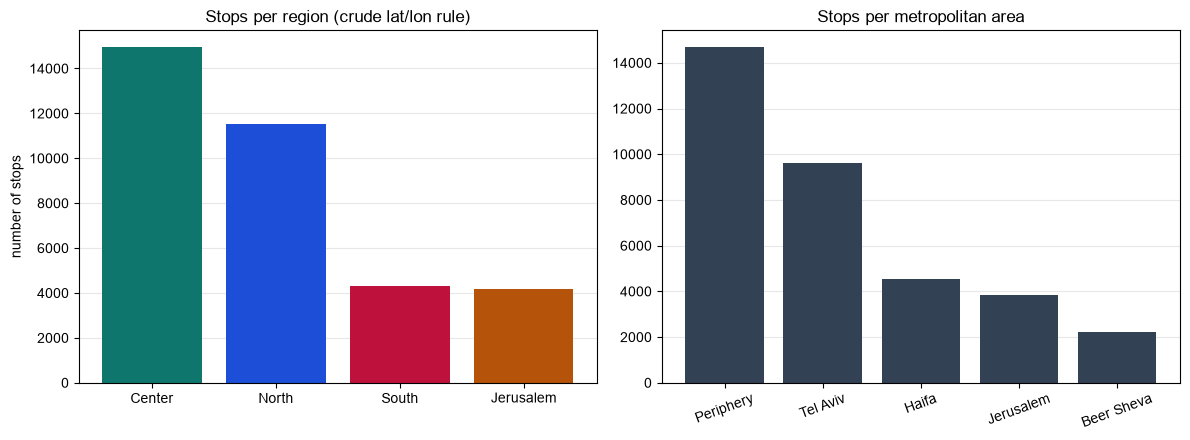

In [9]:
REGION_COLORS = {"North": "#1d4ed8", "Center": "#0f766e", "Jerusalem": "#b45309", "South": "#be123c"}

# --- Figure 1: stops per region and per metro ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
region_counts = stops["region"].value_counts()
axes[0].bar(region_counts.index, region_counts.values,
            color=[REGION_COLORS.get(r, "#64748b") for r in region_counts.index])
axes[0].set_title("Stops per region (crude lat/lon rule)")
axes[0].set_ylabel("number of stops")
metro_counts = stops["metro"].value_counts()
axes[1].bar(metro_counts.index, metro_counts.values, color="#334155")
axes[1].set_title("Stops per metropolitan area")
axes[1].tick_params(axis="x", rotation=20)
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURES / "region_and_metro_counts.png", dpi=150)
plt.show()

### Figure 2 - the map

We plot every cleaned stop in longitude/latitude space, colored by the assigned `region`, and mark the four metro centers. The expected dense coastal strip, Jerusalem corridor, and thin line through the Negev to Eilat should be recognizable. A mirrored coordinate or a point far offshore would stand out here even after passing the broad bounding box. The `cos(latitude)` aspect correction prevents the country from looking artificially wide, while the color bands make the roughness of our region rule visible.

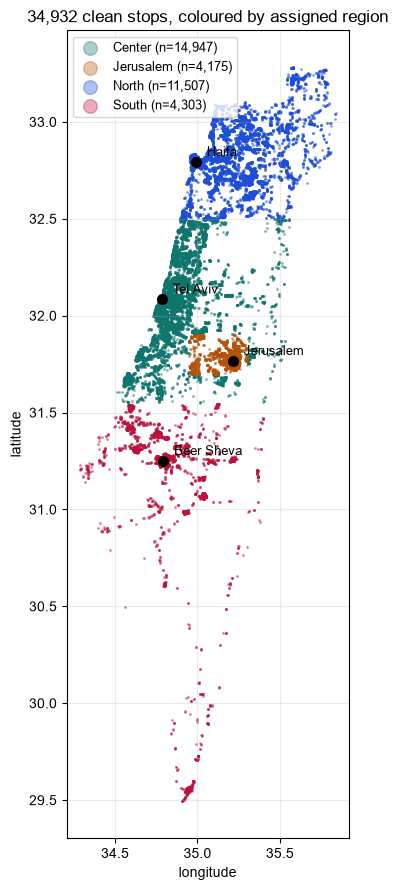

In [10]:
# --- Figure 2: every clean stop on the map, coloured by region ---
fig, ax = plt.subplots(figsize=(6.5, 9))
for name, part in stops.groupby("region"):
    ax.scatter(part["stop_lon"], part["stop_lat"], s=1.5, alpha=0.35,
               color=REGION_COLORS.get(name, "#64748b"),
               label=f"{name} (n={len(part):,d})")
for city, (clat, clon, radius) in METRO_CENTERS.items():
    ax.plot(clon, clat, marker="o", markersize=7, color="black", zorder=5)
    ax.annotate(city, (clon, clat), textcoords="offset points", xytext=(8, 4), fontsize=9, zorder=6)
ax.set_aspect(1.0 / math.cos(math.radians(31.7)))  # keep the country from looking stretched
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"{len(stops):,d} clean stops, coloured by assigned region")
ax.legend(markerscale=8, loc="upper left", fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "stops_map_by_region.png", dpi=150)
plt.show()

### Figure 3 - service composition by mode

This chart puts route count and scheduled-trip count side by side for each GTFS mode. We use a logarithmic y-axis because bus values are much larger and would otherwise flatten the rail and light-rail bars. We are looking at both measures because a mode can have few named routes but run many trips on them; that distinction will matter when trip frequency becomes an edge weight.

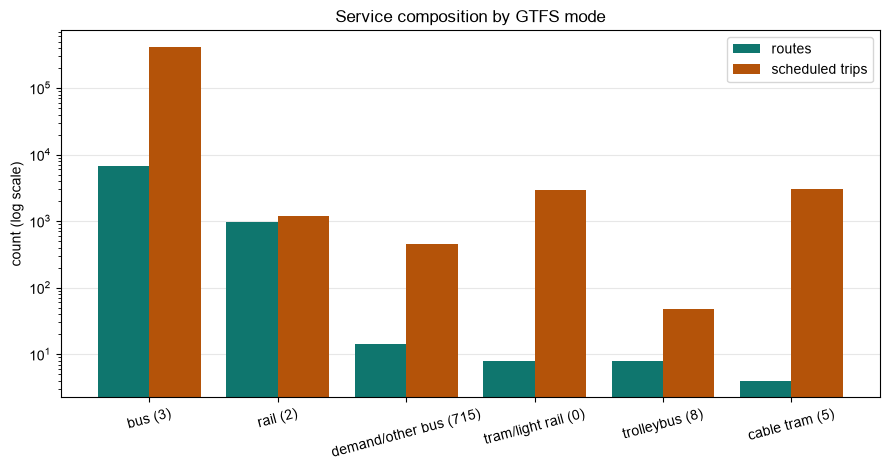

In [11]:
# --- Figure 3: routes and scheduled trips per GTFS mode (log scale) ---
labels = route_types["route_type_label"] + " (" + route_types["route_type"] + ")"
x = np.arange(len(route_types))
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - 0.2, route_types["routes"], width=0.4, label="routes", color="#0f766e")
ax.bar(x + 0.2, route_types["scheduled_trips"], width=0.4, label="scheduled trips", color="#b45309")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_yscale("log")
ax.set_ylabel("count (log scale)")
ax.set_title("Service composition by GTFS mode")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURES / "route_type_distribution.png", dpi=150)
plt.show()

### Figure 4 - operators

We sort operators by scheduled-trip count, keep the top 12, reverse the rows for a readable horizontal bar chart, and save the result. This is a service-concentration check rather than a route-count chart. It also verifies the Hebrew plotting setup with actual agency names; if the labels look reversed, we know the environment-specific text handling needs attention.

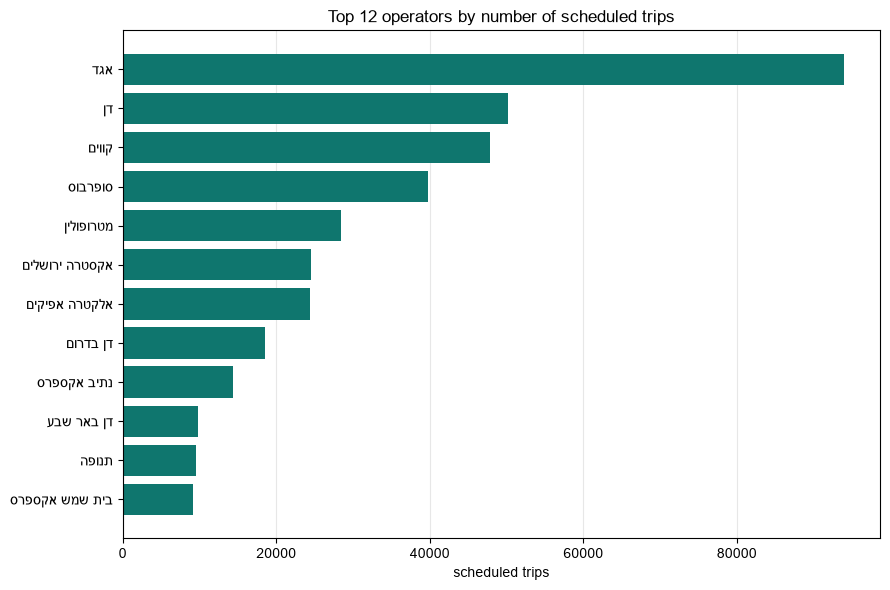

In [12]:
# --- Figure 4: top operators by scheduled trips (Hebrew names via the bidi patch) ---
top_agencies = agency_summary.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_agencies["agency_name"], top_agencies["scheduled_trips"], color="#0f766e")
ax.set_xlabel("scheduled trips")
ax.set_title("Top 12 operators by number of scheduled trips")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURES / "top_agencies_by_trips.png", dpi=150)
plt.show()

## Saving the stage's outputs

We now write the cleaned stops and the typed pass-through lookup tables into the stage's `tables` folder. `utf-8-sig` keeps Hebrew text convenient to open in spreadsheet software, and `index=False` avoids creating an extra unnamed column on the next read.

The JSON file stores the cleaning counts, coordinate bounds, derived-label definitions, category totals, and foreign-key checks. We want these details beside the CSVs so we can inspect how the node set was produced without recomputing everything.

`counts_to_dict()` converts category keys to strings and NumPy counts to ordinary Python integers so `json.dump` works consistently across pandas/NumPy versions.

Writing `trips_clean.csv` is the slowest part and remains conditional on `SAVE_TRIPS_CSV`. The final listing lets us confirm which files were actually created and how large they are.

In [13]:
def counts_to_dict(series):
    """value_counts as a JSON-safe {str: int} dictionary."""
    return {str(k): int(v) for k, v in series.value_counts().items()}

# --- cleaned tables ---
stops.to_csv(TABLES / "stops_clean.csv", index=False, encoding="utf-8-sig")
routes.to_csv(TABLES / "routes_clean.csv", index=False, encoding="utf-8-sig")
agencies.to_csv(TABLES / "agencies_clean.csv", index=False, encoding="utf-8-sig")
if SAVE_TRIPS_CSV:
    trips.to_csv(TABLES / "trips_clean.csv", index=False, encoding="utf-8-sig")
else:
    print("skipped trips_clean.csv (SAVE_TRIPS_CSV = False)")

# --- derived summary tables ---
route_types.to_csv(TABLES / "route_type_distribution.csv", index=False, encoding="utf-8-sig")
agency_summary.to_csv(TABLES / "agency_trip_counts.csv", index=False, encoding="utf-8-sig")

# --- the audit trail ---
report = {
    "generated_by": "notebooks/01_data_preparation.ipynb",
    "gtfs_source_dir": str(DATA),
    "stops_raw": int(len(raw["stops"])),
    "stops_clean": int(len(stops)),
    "stops_dropped": int(len(raw["stops"]) - len(stops)),
    "routes_total": int(len(routes)),
    "trips_total": int(len(trips)),
    "agencies_total": int(len(agencies)),
    "cleaning_steps": cleaning_steps,
    "coordinate_bounds": {
        "lat_min": LAT_MIN, "lat_max": LAT_MAX,
        "lon_min": LON_MIN, "lon_max": LON_MAX,
    },
    "observed_bounds": {
        "lat_min": float(stops["stop_lat"].min()), "lat_max": float(stops["stop_lat"].max()),
        "lon_min": float(stops["stop_lon"].min()), "lon_max": float(stops["stop_lon"].max()),
    },
    "region_rule": (
        "crude first-match lat/lon rule: Jerusalem box (31.70-31.90 lat, 34.95-35.30 lon); "
        "North lat > 32.50; Center lat >= 31.55; South otherwise. Not an administrative geography."
    ),
    "metro_centers": {
        city: {"lat": c[0], "lon": c[1], "radius_km": c[2]} for city, c in METRO_CENTERS.items()
    },
    "region_counts": counts_to_dict(stops["region"]),
    "metro_counts": counts_to_dict(stops["metro"]),
    "location_type_counts": counts_to_dict(stops["location_type"]),
    "route_type_counts": counts_to_dict(routes["route_type"]),
    "integrity": {
        "trips_with_unknown_route_id": orphan_trips,
        "routes_with_unknown_agency_id": orphan_routes,
    },
}

report_path = TABLES / "data_cleaning_report.json"
with open(report_path, "w", encoding="utf-8") as fh:
    json.dump(report, fh, ensure_ascii=False, indent=2)

print("written to", TABLES)
for p in sorted(TABLES.iterdir()):
    print(f"  {p.name:32s} {p.stat().st_size / 1024**2:8.2f} MB")
print()
print(json.dumps({k: v for k, v in report.items() if k != "cleaning_steps"},
                 ensure_ascii=False, indent=2)[:2000])

written to /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/01_data_preparation/tables
  agencies_clean.csv                   0.00 MB
  agency_trip_counts.csv               0.00 MB
  data_cleaning_report.json            0.00 MB
  route_type_distribution.csv          0.00 MB
  routes_clean.csv                     0.93 MB
  stops_clean.csv                      5.23 MB
  trips_clean.csv                     27.07 MB

{
  "generated_by": "notebooks/01_data_preparation.ipynb",
  "gtfs_source_dir": "/Users/seanfourman/Desktop/israel-transit-network-resilience/israel-public-transportation",
  "stops_raw": 34932,
  "stops_clean": 34932,
  "stops_dropped": 0,
  "routes_total": 7792,
  "trips_total": 420133,
  "agencies_total": 37,
  "coordinate_bounds": {
    "lat_min": 29.0,
    "lat_max": 34.0,
    "lon_min": 34.0,
    "lon_max": 36.0
  },
  "observed_bounds": {
    "lat_min": 29.493109,
    "lat_max": 33.282204,
    "lon_min": 34.284672,
    "lon_max": 35.839108
  },
  

## Conclusions

The main result is that this feed does not require any stop rows to be removed. All 34,932 rows survive the numeric-coordinate, latitude, longitude, and duplicate-ID checks. The observed range, about 29.49–33.28° N and 34.28–35.84° E, sits inside our wider 29–34 / 34–36 guard box, and the map has the expected geographic shape. We can therefore use the full raw stops table as the prepared node lookup for this snapshot.

The service tables contain 7,792 routes and 420,133 scheduled trips. Bus records account for 6,796 routes and 412,544 trips, so the combined graph will mainly describe bus connectivity even though it also contains rail and light rail. We need to keep that imbalance in mind whenever we describe a national result.

Our `region` and `metro` columns are useful only as coarse analysis labels. Region is based on latitude bands plus a Jerusalem rectangle, while metro uses four fixed-radius circles. The cross-tab shows that they can disagree, and neither should be read as an official boundary. The pairwise center-distance check shows the metro disks do not overlap, so their order does not change assignments.

The route and agency integrity counts confirm whether the joins used for mode and operator summaries are complete; in this run the printed values are the checks we will rely on downstream. We have deliberately not built any edges yet and have not used `stop_times.txt`. Parent stations also remain in the prepared table so the next notebook can compare them with the identifiers that actually appear in scheduled sequences.